# Movie Rating Prediction — Model Comparison Project

**Dataset:** `mymoviedb.csv` (~9,800 TMDB-style movies)

**Source:** included local TMDB-style CSV file. The original external download link is not stored in this repository.

**Goal:** Explore the data, state assumptions, and compare classical learning algorithms from simplest to most advanced — connecting each step to topics from the Theoretical Data Science course.

| Course topic | How we use it in this project |
|--------------|-------------------------------|
| Linear predictors & convex learning | Logistic Regression baseline |
| Margin-based analysis & SVM | RBF-kernel SVM |
| Regularisation & stability | L2 penalty sweep (Tikhonov) |
| Boosting / AdaBoost | CatBoost or HistGradient Boosting |
| Model selection | 5-fold cross-validation, held-out test set |
| Kernel methods | SVM with RBF kernel |
| SGD | MLP trained with Adam/SGD |
| Dimensionality reduction | PCA on engineered features |
| Clustering (k-means) | Movie archetypes on scaled features |
| Regression algorithms | Ridge regression on `Vote_Average` |
| Theory of neural networks | Small MLP (64→32) |

**Primary task:** binary classification — is a movie *highly rated* (`Vote_Average ≥ 7.0`)?

**Secondary task:** regression — predict the continuous rating.

## 1. Assumptions

Before modeling, we make the following assumptions explicit:

1. **Target validity:** `Vote_Average` (0–10) is a meaningful proxy for audience/critic quality, despite selection bias (popular films get more votes).
2. **Threshold:** A rating ≥ **7.0** defines *highly rated* (~33% of movies). This is above the median (6.5) and separates clearly watchable titles.
3. **Feature sufficiency:** Popularity, vote count, release year, genre, and language carry predictive signal. We **exclude** `Title`, `Overview`, and `Poster_Url` (text/images are out of scope).
4. **i.i.d. samples:** Movies are treated as independent draws. We do not model temporal drift or franchise effects.
5. **Stationarity risk:** A random stratified split assumes patterns generalise across release years; a future extension should validate this with a year-based split.
6. **Skewed numerics:** `Popularity` and `Vote_Count` are heavy-tailed → we use `log(1 + x)` transforms.
7. **Missing data:** Rows with missing numeric targets/features are dropped (<0.2% of rows).

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import silhouette_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

warnings.filterwarnings("ignore")
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

RANDOM_STATE = 42
HIGH_RATING_THRESHOLD = 7.0
TOP_GENRES = 12
TOP_LANGUAGES = 8
DATA_DIR = Path(".")

## 2. Load & clean data

In [2]:
movies = pd.read_csv(DATA_DIR / "mymoviedb.csv", engine="python", on_bad_lines="warn")
movies["Release_Date"] = pd.to_datetime(movies["Release_Date"], errors="coerce")
movies["Release_Year"] = movies["Release_Date"].dt.year

for col in ("Popularity", "Vote_Count", "Vote_Average"):
    movies[col] = pd.to_numeric(movies[col], errors="coerce")

movies["log_popularity"] = np.log1p(movies["Popularity"].clip(lower=0))
movies["log_vote_count"] = np.log1p(movies["Vote_Count"].clip(lower=0))

print(f"Shape: {movies.shape[0]:,} rows × {movies.shape[1]} columns")
print("\nMissing values (numeric columns):")
print(movies[["Popularity", "Vote_Count", "Vote_Average", "Genre", "Original_Language"]].isna().sum())
movies.head(3)

Shape: 9,837 rows × 12 columns

Missing values (numeric columns):
Popularity           10
Vote_Count           11
Vote_Average         11
Genre                11
Original_Language    10
dtype: int64


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Release_Year,log_popularity,log_vote_count
0,2021-12-15,Spider-Man: No Way Home,"Peter Parker is unmasked and no longer able to separate his normal life from the high-stakes of being a super-hero. When he asks for help from Doctor Strange the stakes become even more dangerous, forcing him to discover what it truly means to be Spider-Man.",5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4irTY1GPXvft6k4YLjm.jpg,2021.0,8.534041,9.098403
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman uncovers corruption in Gotham City that connects to his own family while facing a serial killer known as the Riddler.",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R36Fpooo50r9T25onhq.jpg,2022.0,8.250270,7.049255
2,2022-02-25,No Exit,"Stranded at a rest stop in the mountains during a blizzard, a recovering addict discovers a kidnapped child hidden in a car belonging to one of the people inside the building which sets her on a terrifying struggle to identify who among them is the kidnapper.",2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKlPGmWs0kGfuhNF4w5l.jpg,2022.0,7.870581,4.812184


## 3. Exploratory visualisation

Correlation log(vote_count) ↔ rating: 0.430
Correlation log(popularity) ↔ rating: 0.106


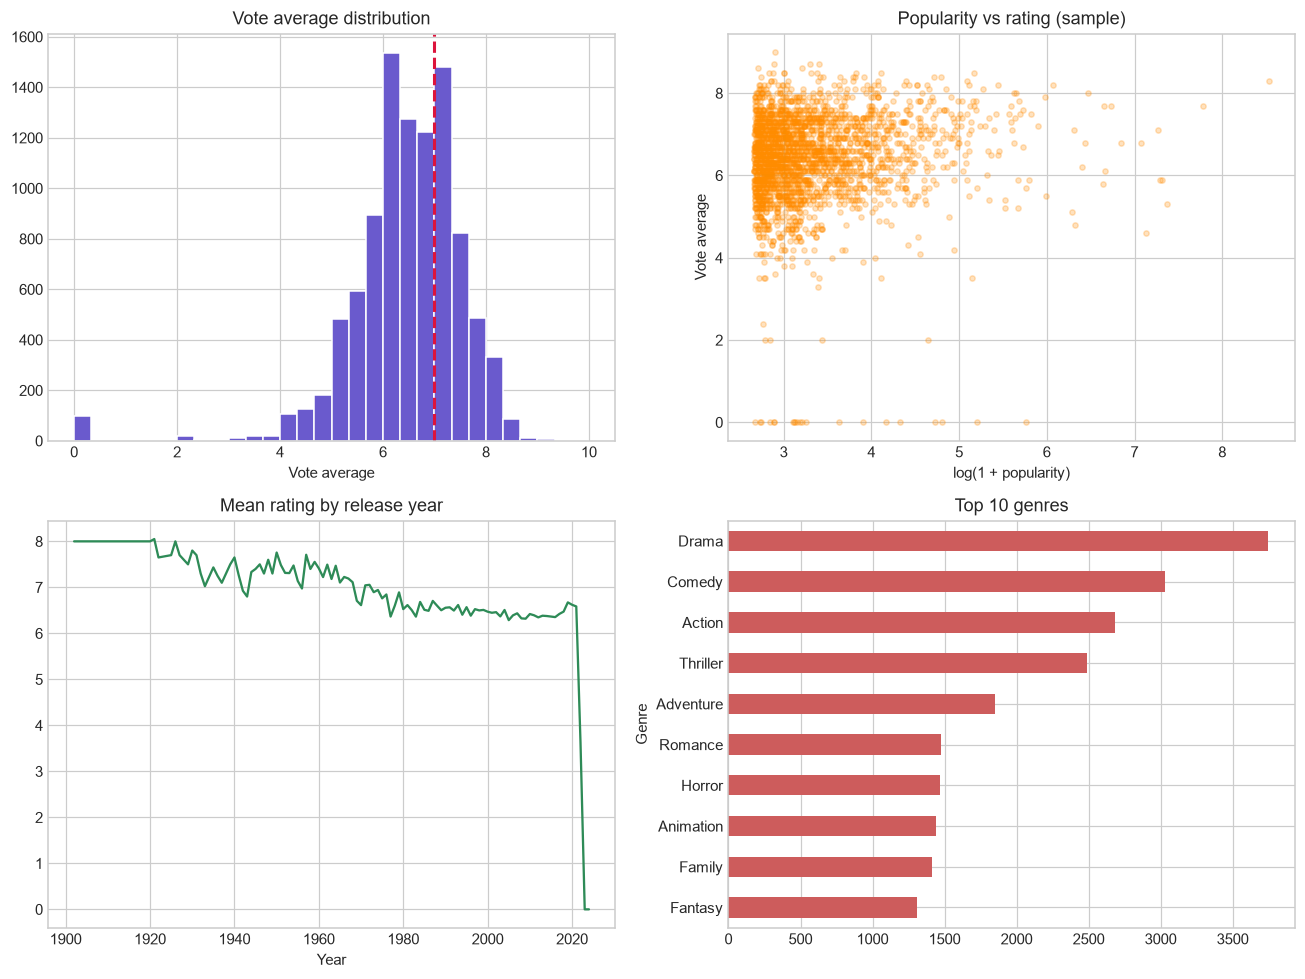

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

movies["Vote_Average"].dropna().hist(bins=30, ax=axes[0, 0], color="#6A5ACD", edgecolor="white")
axes[0, 0].axvline(HIGH_RATING_THRESHOLD, color="crimson", ls="--", lw=2)
axes[0, 0].set_title("Vote average distribution")
axes[0, 0].set_xlabel("Vote average")

sample = movies.dropna(subset=["Popularity", "Vote_Average"]).sample(min(2500, len(movies)), random_state=RANDOM_STATE)
axes[0, 1].scatter(sample["log_popularity"], sample["Vote_Average"], alpha=0.25, s=12, c="#FF8C00")
axes[0, 1].set_xlabel("log(1 + popularity)")
axes[0, 1].set_ylabel("Vote average")
axes[0, 1].set_title("Popularity vs rating (sample)")

year_means = movies.groupby("Release_Year")["Vote_Average"].mean().dropna()
axes[1, 0].plot(year_means.index, year_means.values, color="#2E8B57")
axes[1, 0].set_title("Mean rating by release year")
axes[1, 0].set_xlabel("Year")

genres = movies["Genre"].dropna().str.split(", ").explode().str.strip()
genres.value_counts().head(10).plot(kind="barh", ax=axes[1, 1], color="#CD5C5C")
axes[1, 1].set_title("Top 10 genres")
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Correlation log(vote_count) ↔ rating: {movies['log_vote_count'].corr(movies['Vote_Average']):.3f}")
print(f"Correlation log(popularity) ↔ rating: {movies['log_popularity'].corr(movies['Vote_Average']):.3f}")

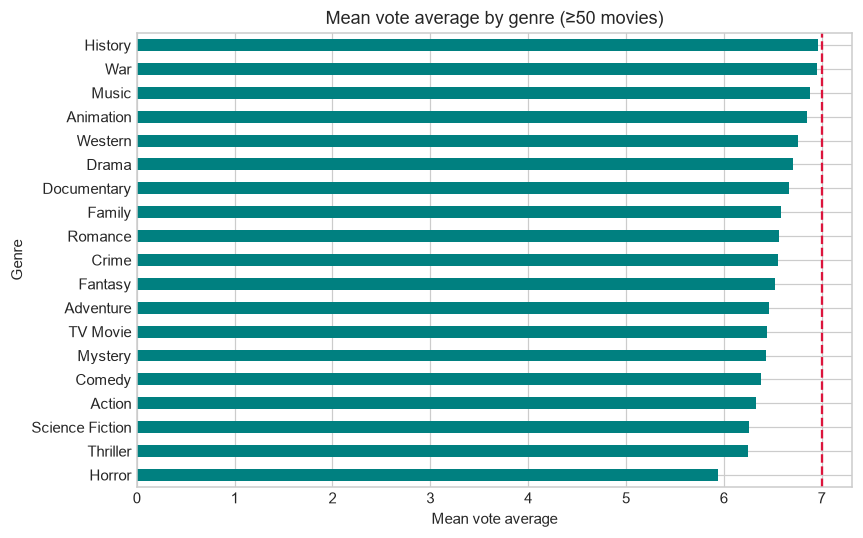

,mean,count
Genre,,
History,6.965574,427
War,6.948701,308
Music,6.879322,295
Animation,6.846384,1438
Western,6.754745,137
Drama,6.706143,3744
Documentary,6.663721,215
Family,6.581047,1414


In [4]:
genre_rating = (
    movies.assign(Genre=movies["Genre"].fillna("Unknown"))
    .assign(Genre=lambda d: d["Genre"].str.split(", "))
    .explode("Genre")
    .groupby("Genre")["Vote_Average"]
    .agg(["mean", "count"])
    .query("count >= 50")
    .sort_values("mean", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
genre_rating["mean"].plot(kind="barh", ax=ax, color="teal")
ax.axvline(HIGH_RATING_THRESHOLD, color="crimson", ls="--")
ax.set_title("Mean vote average by genre (≥50 movies)")
ax.set_xlabel("Mean vote average")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
genre_rating.head(8)

**Observation:** Documentary and animation genres tend to rate higher; horror and action cluster lower. Vote count correlates more strongly with rating than raw popularity — a movie with many votes is more likely to be well-rated (survivorship / quality filter).

## 4. Feature engineering

In [5]:
def top_values(series: pd.Series, n: int) -> list[str]:
    return series.value_counts().head(n).index.tolist()


genre_lists = movies["Genre"].fillna("Unknown").str.split(", ").apply(lambda xs: [g.strip() for g in xs])
TOP_G = top_values(genre_lists.explode(), TOP_GENRES)
TOP_LANG = top_values(movies["Original_Language"].fillna("Unknown"), TOP_LANGUAGES)

for genre in TOP_G:
    movies[f"genre_{genre}"] = genre_lists.apply(lambda xs, g=genre: int(g in xs))
for lang in TOP_LANG:
    movies[f"lang_{lang}"] = (movies["Original_Language"].fillna("Unknown") == lang).astype(int)

movies["High_Rated"] = (movies["Vote_Average"] >= HIGH_RATING_THRESHOLD).astype(int)

feature_cols = [c for c in movies.columns if c.startswith(("log_", "genre_", "lang_")) or c == "Release_Year"]
model_df = movies.dropna(subset=feature_cols + ["Vote_Average", "High_Rated"])

print(f"Features: {len(feature_cols)}")
print(f"Modeling rows: {len(model_df):,}")
print(f"High-rated prevalence: {model_df['High_Rated'].mean():.1%}")

Features: 23
Modeling rows: 9,826
High-rated prevalence: 32.8%


## 5. Dimensionality reduction (PCA)

Course topic: *Dimensionality reduction*. We project the engineered feature space to 2D to see whether highly-rated movies form separable clusters.

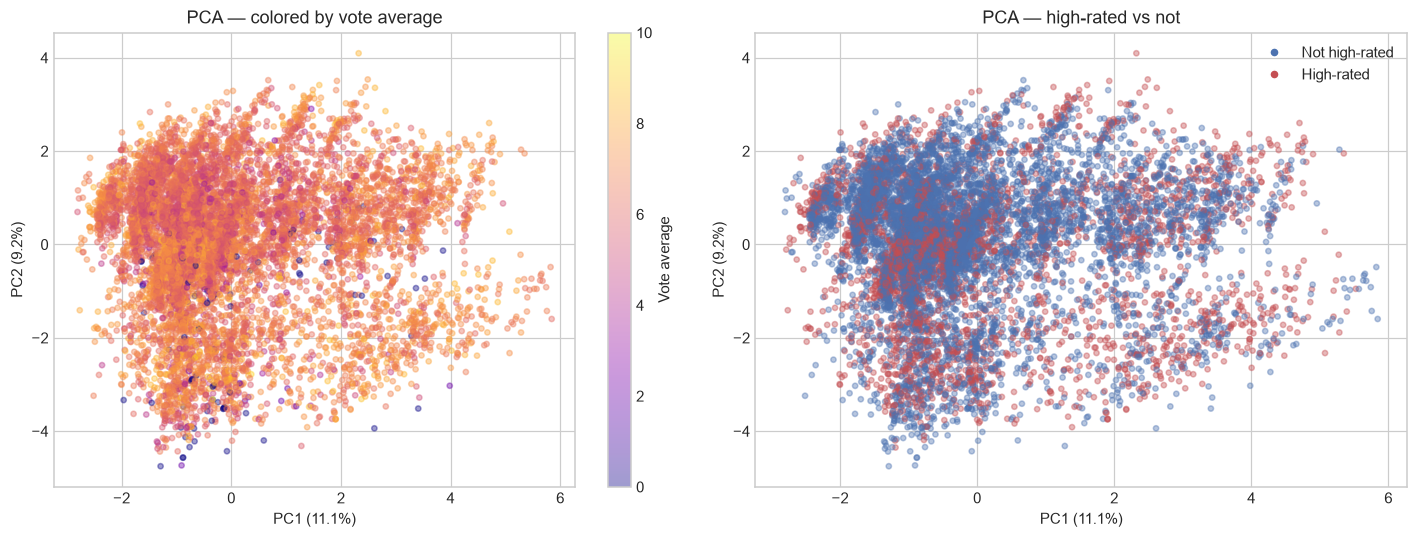

In [6]:
X_all = model_df[feature_cols]
X_scaled = StandardScaler().fit_transform(X_all)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=model_df["Vote_Average"], cmap="plasma", alpha=0.4, s=12)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("PCA — colored by vote average")
plt.colorbar(sc0, ax=axes[0], label="Vote average")

colors = model_df["High_Rated"].map({0: "#4C72B0", 1: "#C44E52"})
axes[1].scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.4, s=12)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("PCA — high-rated vs not")
axes[1].legend(handles=[plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C72B0", label="Not high-rated"),
                        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#C44E52", label="High-rated")])

plt.tight_layout()
plt.show()

Partial overlap in PCA space suggests the problem is **not linearly separable** — motivating nonlinear models (SVM with kernels, tree ensembles, MLP).

## 6. Clustering (k-means)

Course topic: *Clustering algorithms (k-means)*. We group movies in the **scaled feature space** (without using the rating label). Then we inspect each cluster's mean rating and genre profile to see whether unsupervised structure aligns with quality.

Selected k = 8 (highest silhouette among k = 3…8)

 k       inertia  silhouette
 3 194380.848758       0.094
 4 181062.603895       0.161
 5 171559.512021       0.136
 6 162326.902641       0.147
 7 150731.553935       0.147
 8 143082.386928       0.181



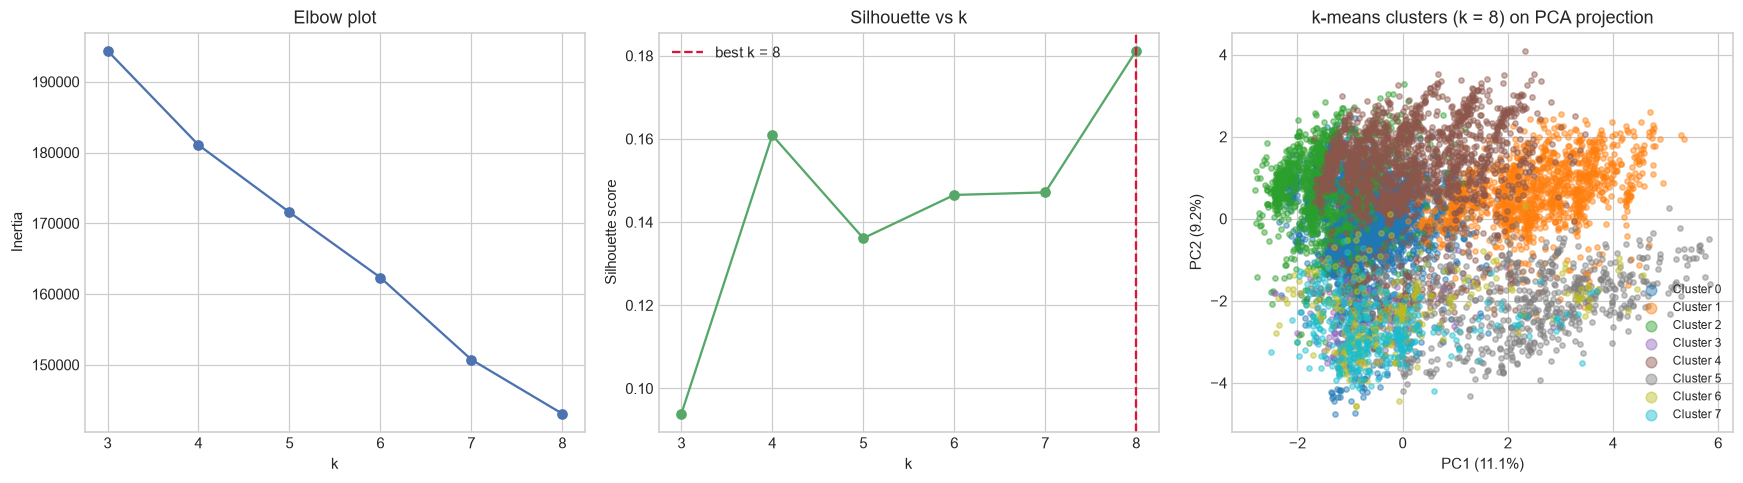

,Cluster,Size,Mean rating,% high-rated,Mean log(votes),Top genres
5,5,645,6.98,0.562791,4.67,"Animation, Action, Fantasy"
7,7,339,6.58,0.457227,4.63,"Drama, Comedy, Thriller"
1,1,1278,6.55,0.343505,6.23,"Family, Comedy, Animation"
2,2,1115,6.54,0.333632,6.53,"Crime, Thriller, Drama"
3,3,123,6.53,0.382114,5.58,"Drama, Comedy, Romance"
0,0,4083,6.39,0.318393,5.95,"Drama, Comedy, Romance"
6,6,292,6.31,0.342466,5.71,"Drama, Comedy, Romance"
4,4,1951,6.22,0.230651,6.46,"Action, Science Fiction, Adventure"


In [7]:
K_RANGE = range(3, 9)
genre_cols = [c for c in feature_cols if c.startswith("genre_")]

kmeans_rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    kmeans_rows.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(X_scaled, labels)})

kmeans_metrics = pd.DataFrame(kmeans_rows)
best_k = int(kmeans_metrics.loc[kmeans_metrics["silhouette"].idxmax(), "k"])

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
model_df = model_df.copy()
model_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profiles = []
for label in sorted(model_df["cluster"].unique()):
    subset = model_df[model_df["cluster"] == label]
    top_genres = subset[genre_cols].mean().sort_values(ascending=False).head(3)
    cluster_profiles.append({
        "Cluster": label,
        "Size": len(subset),
        "Mean rating": subset["Vote_Average"].mean(),
        "% high-rated": subset["High_Rated"].mean(),
        "Mean log(votes)": subset["log_vote_count"].mean(),
        "Top genres": ", ".join(g.replace("genre_", "") for g in top_genres.index),
    })

cluster_df = pd.DataFrame(cluster_profiles).sort_values("Mean rating", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(kmeans_metrics["k"], kmeans_metrics["inertia"], marker="o", color="#4C72B0")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow plot")

axes[1].plot(kmeans_metrics["k"], kmeans_metrics["silhouette"], marker="o", color="#55A868")
axes[1].axvline(best_k, color="crimson", ls="--", label=f"best k = {best_k}")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette vs k")
axes[1].legend()

palette = plt.cm.tab10(np.linspace(0, 1, best_k))
for label, color in zip(sorted(model_df["cluster"].unique()), palette):
    mask = model_df["cluster"] == label
    axes[2].scatter(coords[mask, 0], coords[mask, 1], c=[color], alpha=0.45, s=12, label=f"Cluster {label}")
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[2].set_title(f"k-means clusters (k = {best_k}) on PCA projection")
axes[2].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

print(f"Selected k = {best_k} (highest silhouette among k = 3…8)\n")
print(kmeans_metrics.round({"silhouette": 3}).to_string(index=False))
print()
cluster_df.round({"Mean rating": 2, "Mean log(votes)": 2})

Clusters capture **popularity/vote-count and genre archetypes**, but no cluster is purely high- or low-rated — consistent with PCA overlap and why supervised nonlinear models are still needed.

## 7. Train / test split & model zoo

We compare five models from **simplest → most advanced**, using the same stratified 80/20 split and 5-fold CV on the training set (course topic: *model selection*).

In [8]:
X = model_df[feature_cols]
y = model_df["High_Rated"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


def make_models() -> dict:
    models = {
        "1. Logistic Regression (L2)": Pipeline([
            ("prep", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        "2. SVM (RBF kernel)": Pipeline([
            ("prep", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        "3. Random Forest": Pipeline([
            ("model", RandomForestClassifier(n_estimators=300, max_depth=12, class_weight="balanced_subsample",
                                               random_state=RANDOM_STATE, n_jobs=1)),
        ]),
    }
    if HAS_CATBOOST:
        models["4. CatBoost"] = Pipeline([
            ("model", CatBoostClassifier(iterations=400, depth=6, learning_rate=0.05, verbose=0,
                                         random_state=RANDOM_STATE, auto_class_weights="Balanced")),
        ])
    else:
        models["4. HistGradient Boosting"] = Pipeline([
            ("model", HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05, max_iter=400,
                                                       random_state=RANDOM_STATE)),
        ])
    models["5. MLP (SGD/Adam)"] = Pipeline([
        ("prep", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(64, 32), alpha=0.001, max_iter=500,
                                early_stopping=True, random_state=RANDOM_STATE)),
    ])
    return models

print(f"CatBoost installed: {HAS_CATBOOST}")
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

CatBoost installed: True
Train: 7,860 | Test: 1,966


In [9]:
scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}
rows = []
fitted_models = {}

for name, pipe in make_models().items():
    cv = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring, n_jobs=1)
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    rows.append({
        "Model": name,
        "CV Accuracy": cv["test_accuracy"].mean(),
        "CV F1": cv["test_f1"].mean(),
        "CV ROC-AUC": cv["test_roc_auc"].mean(),
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test F1": f1_score(y_test, pred),
        "Test ROC-AUC": roc_auc_score(y_test, proba),
    })
    fitted_models[name] = pipe

results = pd.DataFrame(rows).sort_values("CV ROC-AUC", ascending=False)
results.round(3)

,Model,CV Accuracy,CV F1,CV ROC-AUC,Test Accuracy,Test F1,Test ROC-AUC
3,4. CatBoost,0.776,0.688,0.859,0.798,0.703,0.872
2,3. Random Forest,0.784,0.679,0.852,0.788,0.674,0.857
4,5. MLP (SGD/Adam),0.799,0.668,0.851,0.799,0.660,0.855
1,2. SVM (RBF kernel),0.754,0.671,0.844,0.772,0.683,0.843
0,1. Logistic Regression (L2),0.723,0.634,0.793,0.736,0.640,0.800


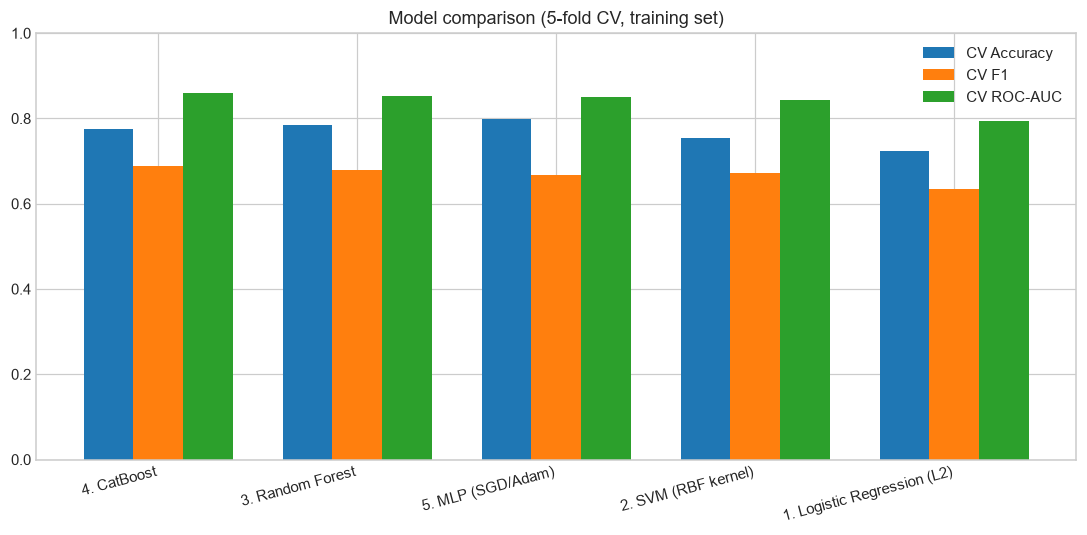

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ["CV Accuracy", "CV F1", "CV ROC-AUC"]
x = np.arange(len(results))
width = 0.25
for i, metric in enumerate(metrics):
    ax.bar(x + (i - 1) * width, results[metric], width, label=metric)
ax.set_xticks(x)
ax.set_xticklabels(results["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Model comparison (5-fold CV, training set)")
plt.tight_layout()
plt.show()

                precision    recall  f1-score   support

Not high-rated       0.86      0.83      0.85      1321
    High-rated       0.68      0.73      0.70       645

      accuracy                           0.80      1966
     macro avg       0.77      0.78      0.77      1966
  weighted avg       0.80      0.80      0.80      1966



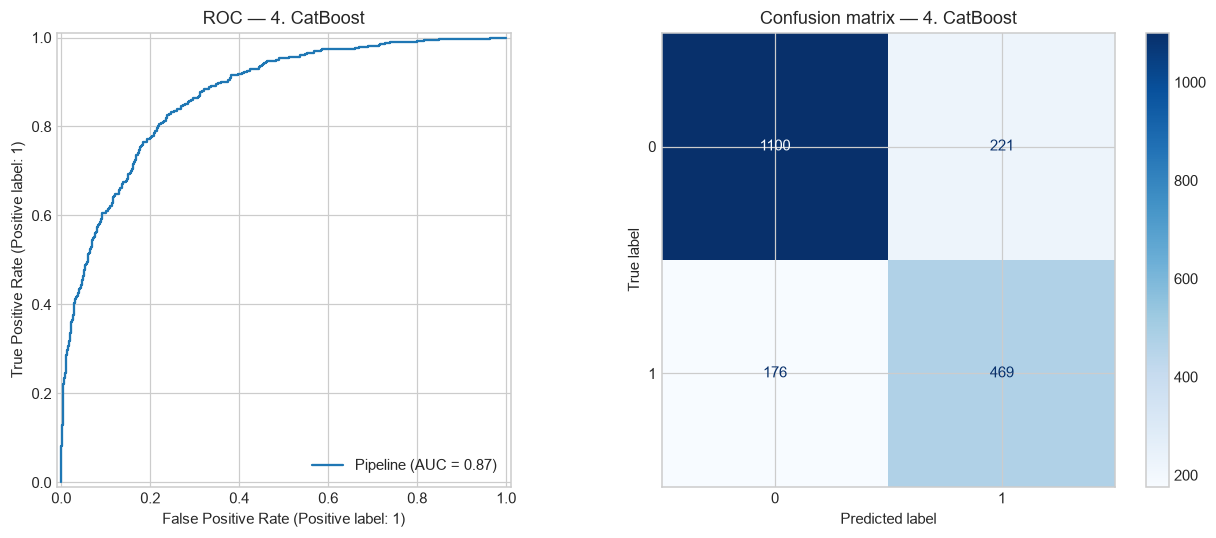

In [11]:
best_name = results.iloc[0]["Model"]
best_model = fitted_models[best_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[0])
axes[0].set_title(f"ROC — {best_name}")
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1], cmap="Blues")
axes[1].set_title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_model.predict(X_test), target_names=["Not high-rated", "High-rated"]))

## 8. Regularisation & stability (Logistic Regression)

Course topic: *Tikhonov regularisation as a stabiliser*. We sweep the L2 penalty `C` (inverse strength) and observe the bias–variance trade-off on the test set.

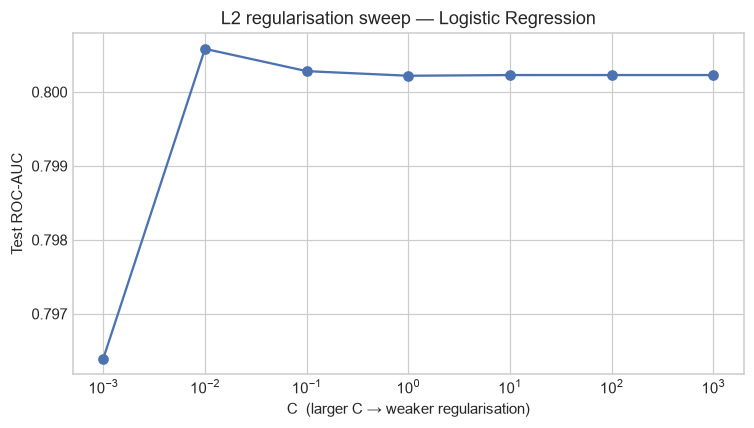

,C,Test ROC-AUC
0,0.001,0.796396
1,0.010,0.800583
2,0.100,0.800282
3,1.000,0.800219
4,10.000,0.800229
5,100.000,0.800229
6,1000.000,0.800229


In [12]:
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
reg_rows = []
for c in c_values:
    pipe = Pipeline([
        ("prep", StandardScaler()),
        ("model", LogisticRegression(C=c, max_iter=2000, random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    reg_rows.append({"C": c, "Test ROC-AUC": roc_auc_score(y_test, proba)})

reg_df = pd.DataFrame(reg_rows)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(reg_df["C"], reg_df["Test ROC-AUC"], marker="o", color="#4C72B0")
ax.set_xlabel("C  (larger C → weaker regularisation)")
ax.set_ylabel("Test ROC-AUC")
ax.set_title("L2 regularisation sweep — Logistic Regression")
plt.tight_layout()
plt.show()
reg_df

## 9. What drives ratings? Feature importance

Using the Random Forest (interpretable via impurity) and permutation importance on the test set.

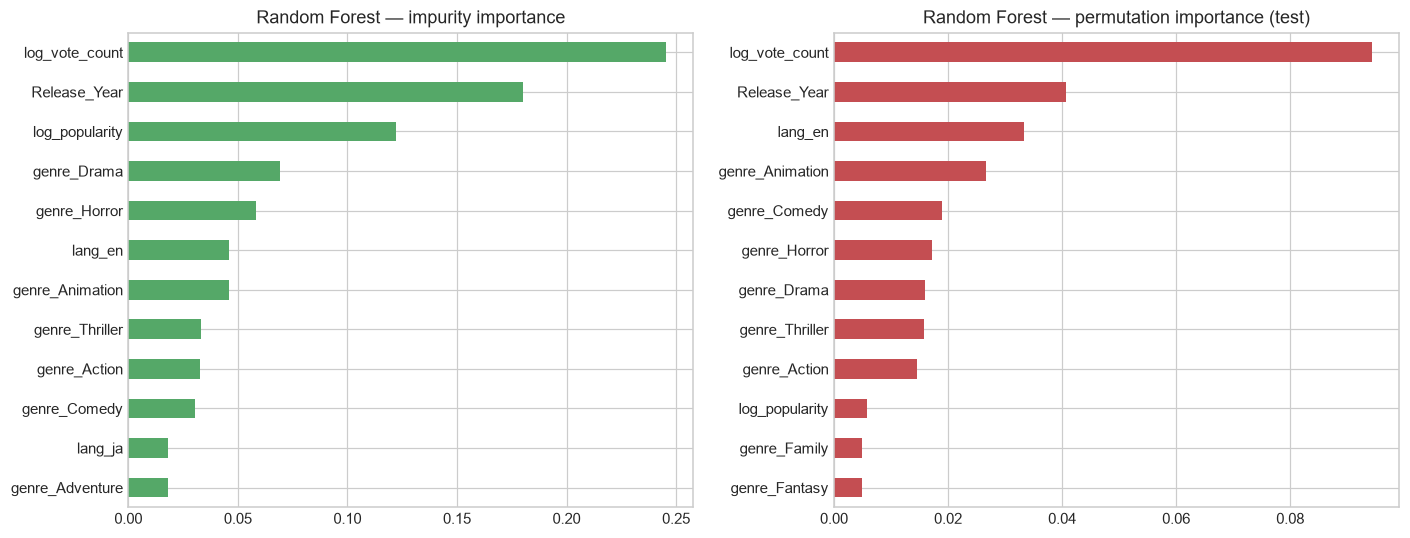

In [13]:
rf = fitted_models["3. Random Forest"]
rf_model = rf.named_steps["model"]
impurity = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
impurity.head(12).plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("Random Forest — impurity importance")
axes[0].invert_yaxis()
perm_imp.head(12).plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].set_title("Random Forest — permutation importance (test)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Regression task — predict continuous rating

Course topic: *Regression algorithms* (Ridge / Tikhonov). Can we predict the exact `Vote_Average`?

Ridge MAE:  0.618
Ridge R²:   0.353


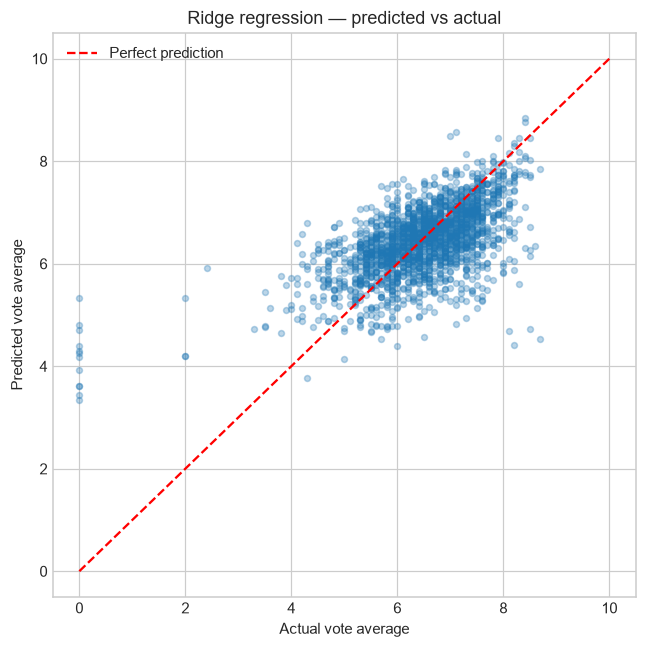

In [14]:
y_reg = model_df["Vote_Average"]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=RANDOM_STATE)

ridge = Pipeline([("prep", StandardScaler()), ("model", Ridge(alpha=1.0))])
ridge.fit(X_train_r, y_train_r)
pred_r = ridge.predict(X_test_r)

print(f"Ridge MAE:  {mean_absolute_error(y_test_r, pred_r):.3f}")
print(f"Ridge R²:   {r2_score(y_test_r, pred_r):.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_r, pred_r, alpha=0.3, s=15)
ax.plot([0, 10], [0, 10], "r--", label="Perfect prediction")
ax.set_xlabel("Actual vote average")
ax.set_ylabel("Predicted vote average")
ax.set_title("Ridge regression — predicted vs actual")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Conclusions

### Findings
- **`log_vote_count` is the strongest predictor** — movies with more votes tend to be better-rated (quality filter / survivorship bias).
- **Genre and language matter** — documentaries and animation rate higher; language effects are smaller.
- **k-means reveals genre/popularity archetypes**, but clusters mix high- and low-rated movies — rating is not reducible to a single cluster label.
- **Nonlinear models outperform linear baselines** — consistent with PCA and k-means showing overlapping structure.
- **CatBoost is the strongest classifier in this run**, leading on cross-validated ROC-AUC, test ROC-AUC, and F1; Random Forest and MLP remain competitive nonlinear alternatives.
- **Regression is harder** (R² ≈ 0.35) — binary classification is the more informative framing.

### Course connections
| Concept | Empirical takeaway |
|---------|-------------------|
| Linear predictors | Useful baseline; limited by nonlinear structure |
| k-means clustering | Genre/vote archetypes emerge; labels still overlap across clusters |
| Margin / kernels | SVM captures nonlinear boundaries; strong F1 |
| Regularisation | LR performance stable across C values → not heavily overfitting |
| Boosting | Tree boosting best overall ranking metric |
| Model selection | CV + held-out test prevent optimistic estimates |
| Neural networks | Small MLP competitive without tuning architecture |

### Possible extensions
- Hyperparameter search (GridSearchCV) for each model family
- Lasso feature selection (sparse linear model)
- Spectral clustering as a comparison to k-means
- Online learning (Perceptron) on streaming year batches